In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Functions

In [75]:
def pca_from_dataframes(
    df_list,
    labels,
    columns,
    figsize=(6, 5),
    dpi=150,
    show=True,
):
    """
    PCA from list of dataframes.

    Parameters
    ----------
    df_list : list[pd.DataFrame]
        One dataframe per sample.

    labels : list[str]
        Sample names.

    columns : list[str]
        Numerical features for PCA.

    Returns
    -------
    pca_df
    pca
    """

    dfs = []

    for df, label in zip(df_list, labels):

        tmp = df[columns].copy()
        tmp["sample"] = label

        dfs.append(tmp)

    data = pd.concat(dfs, ignore_index=True)

    X = data[columns]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)

    pcs = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(
        pcs,
        columns=["PC1", "PC2"]
    )

    pca_df["sample"] = data["sample"].values

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi
    )

    for label in labels:

        subset = pca_df[
            pca_df["sample"] == label
        ]

        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            alpha=0.6,
            label=label,
            s=20
        )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    if show:
        plt.show()

    return pca_df, pca

def beautiful_pca_plot(
    pca_df,
    centroids,
    explained_variance=None,
    figsize=(8, 6),
    dpi=300,
):
    
    colors = {
        "WT": "#4C72B0",
        "MGS1": "#55A868",
        "MGS2": "#C44E52",
        "MGS3": "#8172B2",
        "MGS4": "#CCB974",
        "MGS5": "#64B5CD",
    }

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi
    )

    # -------------------------
    # Cells
    # -------------------------

    for sample in pca_df["sample"].unique():

        subset = pca_df[
            pca_df["sample"] == sample
        ]

        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            s=30,
            alpha=0.35,
            color=colors.get(sample),
            label=sample,
            edgecolors="none"
        )

    # -------------------------
    # Centroids
    # -------------------------

    for sample in centroids.index:

        x = centroids.loc[sample, "PC1"]
        y = centroids.loc[sample, "PC2"]

        ax.scatter(
            x,
            y,
            marker="X",
            s=100,
            color=colors.get(sample),
            edgecolor="black",
            linewidth=0.5,
            zorder=10,
        )

        ax.annotate(
            sample,
            (x, y),
            xytext=(-10, 5),
            textcoords="offset points",
            fontsize=6,
            weight="bold"
        )

    # -------------------------
    # Labels
    # -------------------------

    if explained_variance is not None:

        ax.set_xlabel(
            f"PC1 ({explained_variance[0]*100:.1f}%)",
            fontsize=12
        )

        ax.set_ylabel(
            f"PC2 ({explained_variance[1]*100:.1f}%)",
            fontsize=12
        )

    else:
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

    # -------------------------
    # Style
    # -------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        alpha=0.2,
        linestyle="--"
    )

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    return fig, ax

def compare_pca_to_wt(
    pca_df,
    wt_label="WT",
    test="mannwhitney"
):
    results = []

    wt_pc1 = pca_df.loc[
        pca_df["sample"] == wt_label,
        "PC1"
    ]

    wt_pc2 = pca_df.loc[
        pca_df["sample"] == wt_label,
        "PC2"
    ]

    mutants = [
        x for x in pca_df["sample"].unique()
        if x != wt_label
    ]

    for mutant in mutants:

        mut_pc1 = pca_df.loc[
            pca_df["sample"] == mutant,
            "PC1"
        ]

        mut_pc2 = pca_df.loc[
            pca_df["sample"] == mutant,
            "PC2"
        ]

        stat1, p1 = mannwhitneyu(
            wt_pc1,
            mut_pc1,
            alternative="two-sided"
        )

        stat2, p2 = mannwhitneyu(
            wt_pc2,
            mut_pc2,
            alternative="two-sided"
        )

        results.append({
            "sample": mutant,

            "WT_PC1_mean": wt_pc1.mean(),
            "Mut_PC1_mean": mut_pc1.mean(),
            "PC1_p": p1,

            "WT_PC2_mean": wt_pc2.mean(),
            "Mut_PC2_mean": mut_pc2.mean(),
            "PC2_p": p2,
        })

    results = pd.DataFrame(results)
    results = results[['sample', 'PC1_p', 'PC2_p']]
    
    return results

# Load data

In [2]:
data = [
        {'name': 'WT', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/WT/foci_aggregation.csv"},
        {'name': 'MGS1', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS1/foci_aggregation.csv"},
        {'name': 'MGS2', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS2/foci_aggregation.csv"},
        {'name':'MGS3', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS3/foci_aggregation.csv"},
        {'name':'MGS4', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS4/foci_aggregation.csv"},
        {'name':'MGS5', 'path': "/mnt/c/users/elopatukhin/Desktop/020226/MGS5/foci_aggregation.csv"},
    ]

labels = [df['name'] for df in data]
print(labels)

['WT', 'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5']


In [3]:
dfs = []
for item in data:
        p = item["path"]
        df = pd.read_csv(p)
        dfs.append(df)

N_files = len(dfs)
print(f"Loaded {N_files} dataframes.")

Loaded 6 dataframes.


In [4]:
# Names of columns
print(dfs[0].columns)

Index(['filname', 'n_foci', 'sigma_nm_mean', 'sigma_nm_sd',
       'intensity_photon_mean', 'intensity_photon_sd', 'sigma_pixel_mean',
       'sigma_pixel_sd', 'foci_MFI_mean', 'foci_MFI_sd'],
      dtype='str')


# PCA

## Graphs

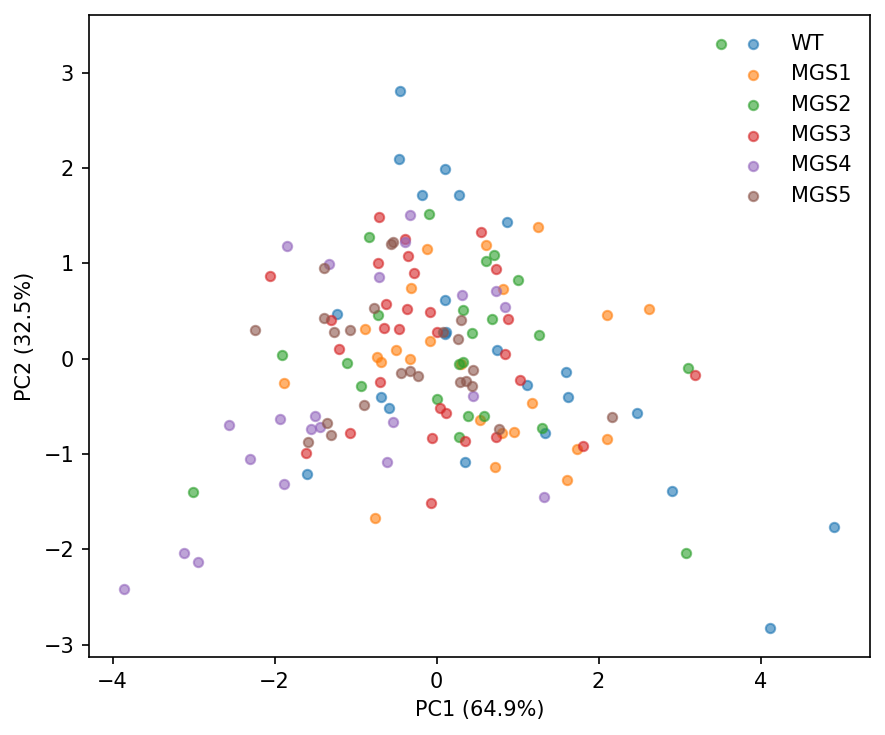

In [76]:
pca_df, pca = pca_from_dataframes(
    df_list=dfs,
    labels=labels,
    columns=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ]
)

In [10]:
# How much of the total variation in your data is explained by each principal component
print(pca.explained_variance_ratio_)

[0.64865022 0.32540055]


## Explanation of each component

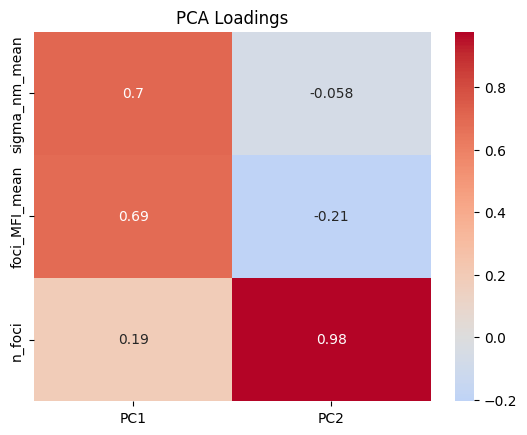

In [20]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ],
    columns=["PC1", "PC2"]
)

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.show()

## Find center of mass

In [23]:
centroids = (
    pca_df
    .groupby("sample")[["PC1", "PC2"]]
    .mean()
)

wt = centroids.loc["WT"]

distances = {}

for sample in centroids.index:

    distances[sample] = np.linalg.norm(
        centroids.loc[sample] - wt
    )

for k, v in distances.items():
    print(k, v)

MGS1 0.35099545608107036
MGS2 0.38219494157063744
MGS3 0.8457812413453064
MGS4 1.9637525501018251
MGS5 1.1913002982996974
WT 0.0


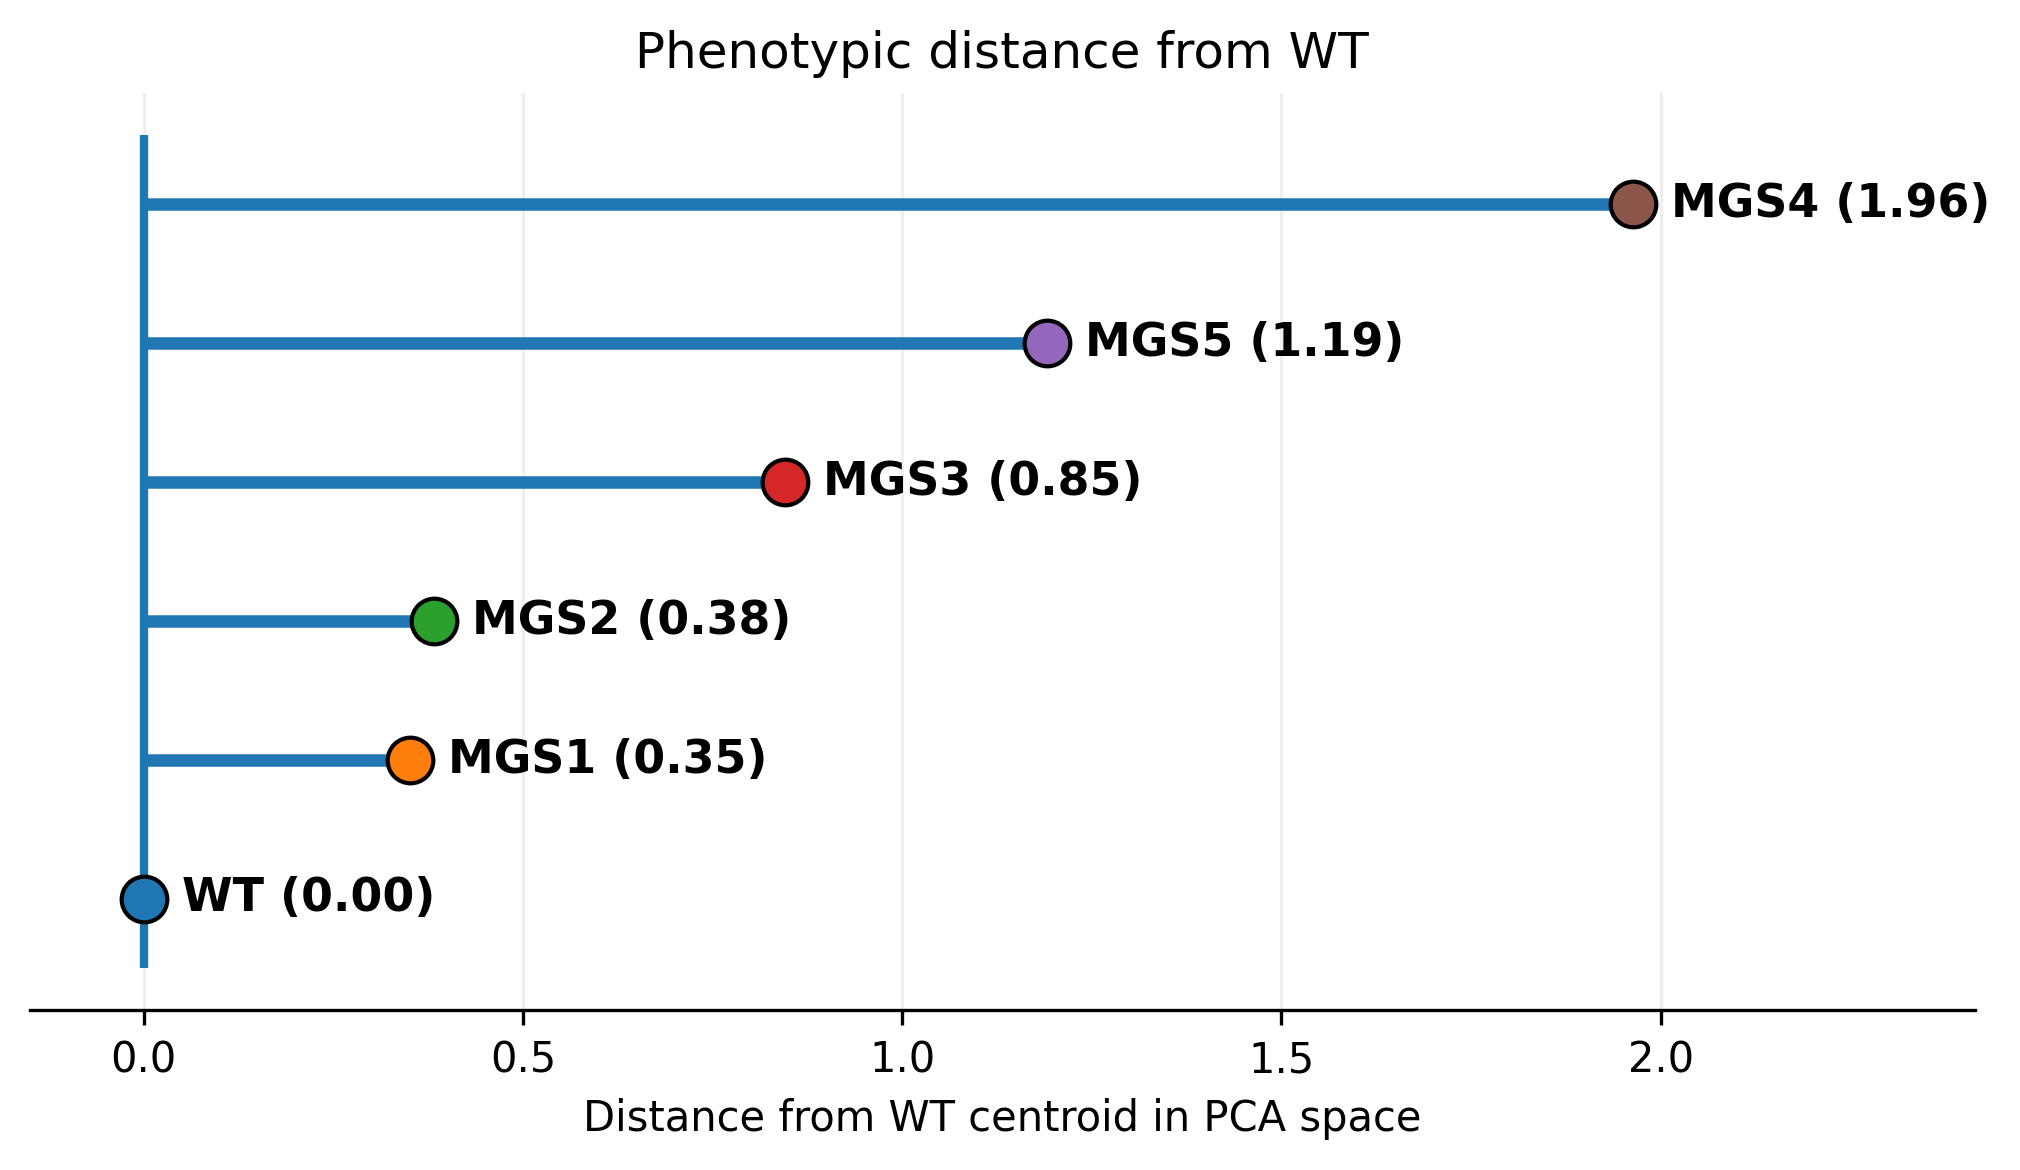

In [80]:
df = pd.Series(distances).sort_values()

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

y_positions = range(len(df))

# vertical WT trunk
ax.vlines(
    x=0,
    ymin=-0.5,
    ymax=len(df)-0.5,
    linewidth=2
)

# branches
for y, (sample, distance) in zip(y_positions, df.items()):

    ax.hlines(
        y=y,
        xmin=0,
        xmax=distance,
        linewidth=3
    )

    ax.scatter(
        distance,
        y,
        s=120,
        zorder=3,
        edgecolor="black"
    )

    ax.text(
        distance + 0.05,
        y,
        f"{sample} ({distance:.2f})",
        va="center",
        fontsize=11,
        weight="bold"
    )


ax.set_xlabel("Distance from WT centroid in PCA space")
ax.set_yticks([])
ax.set_xlim(-0.15, df.max() + 0.45)

ax.set_title("Phenotypic distance from WT")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

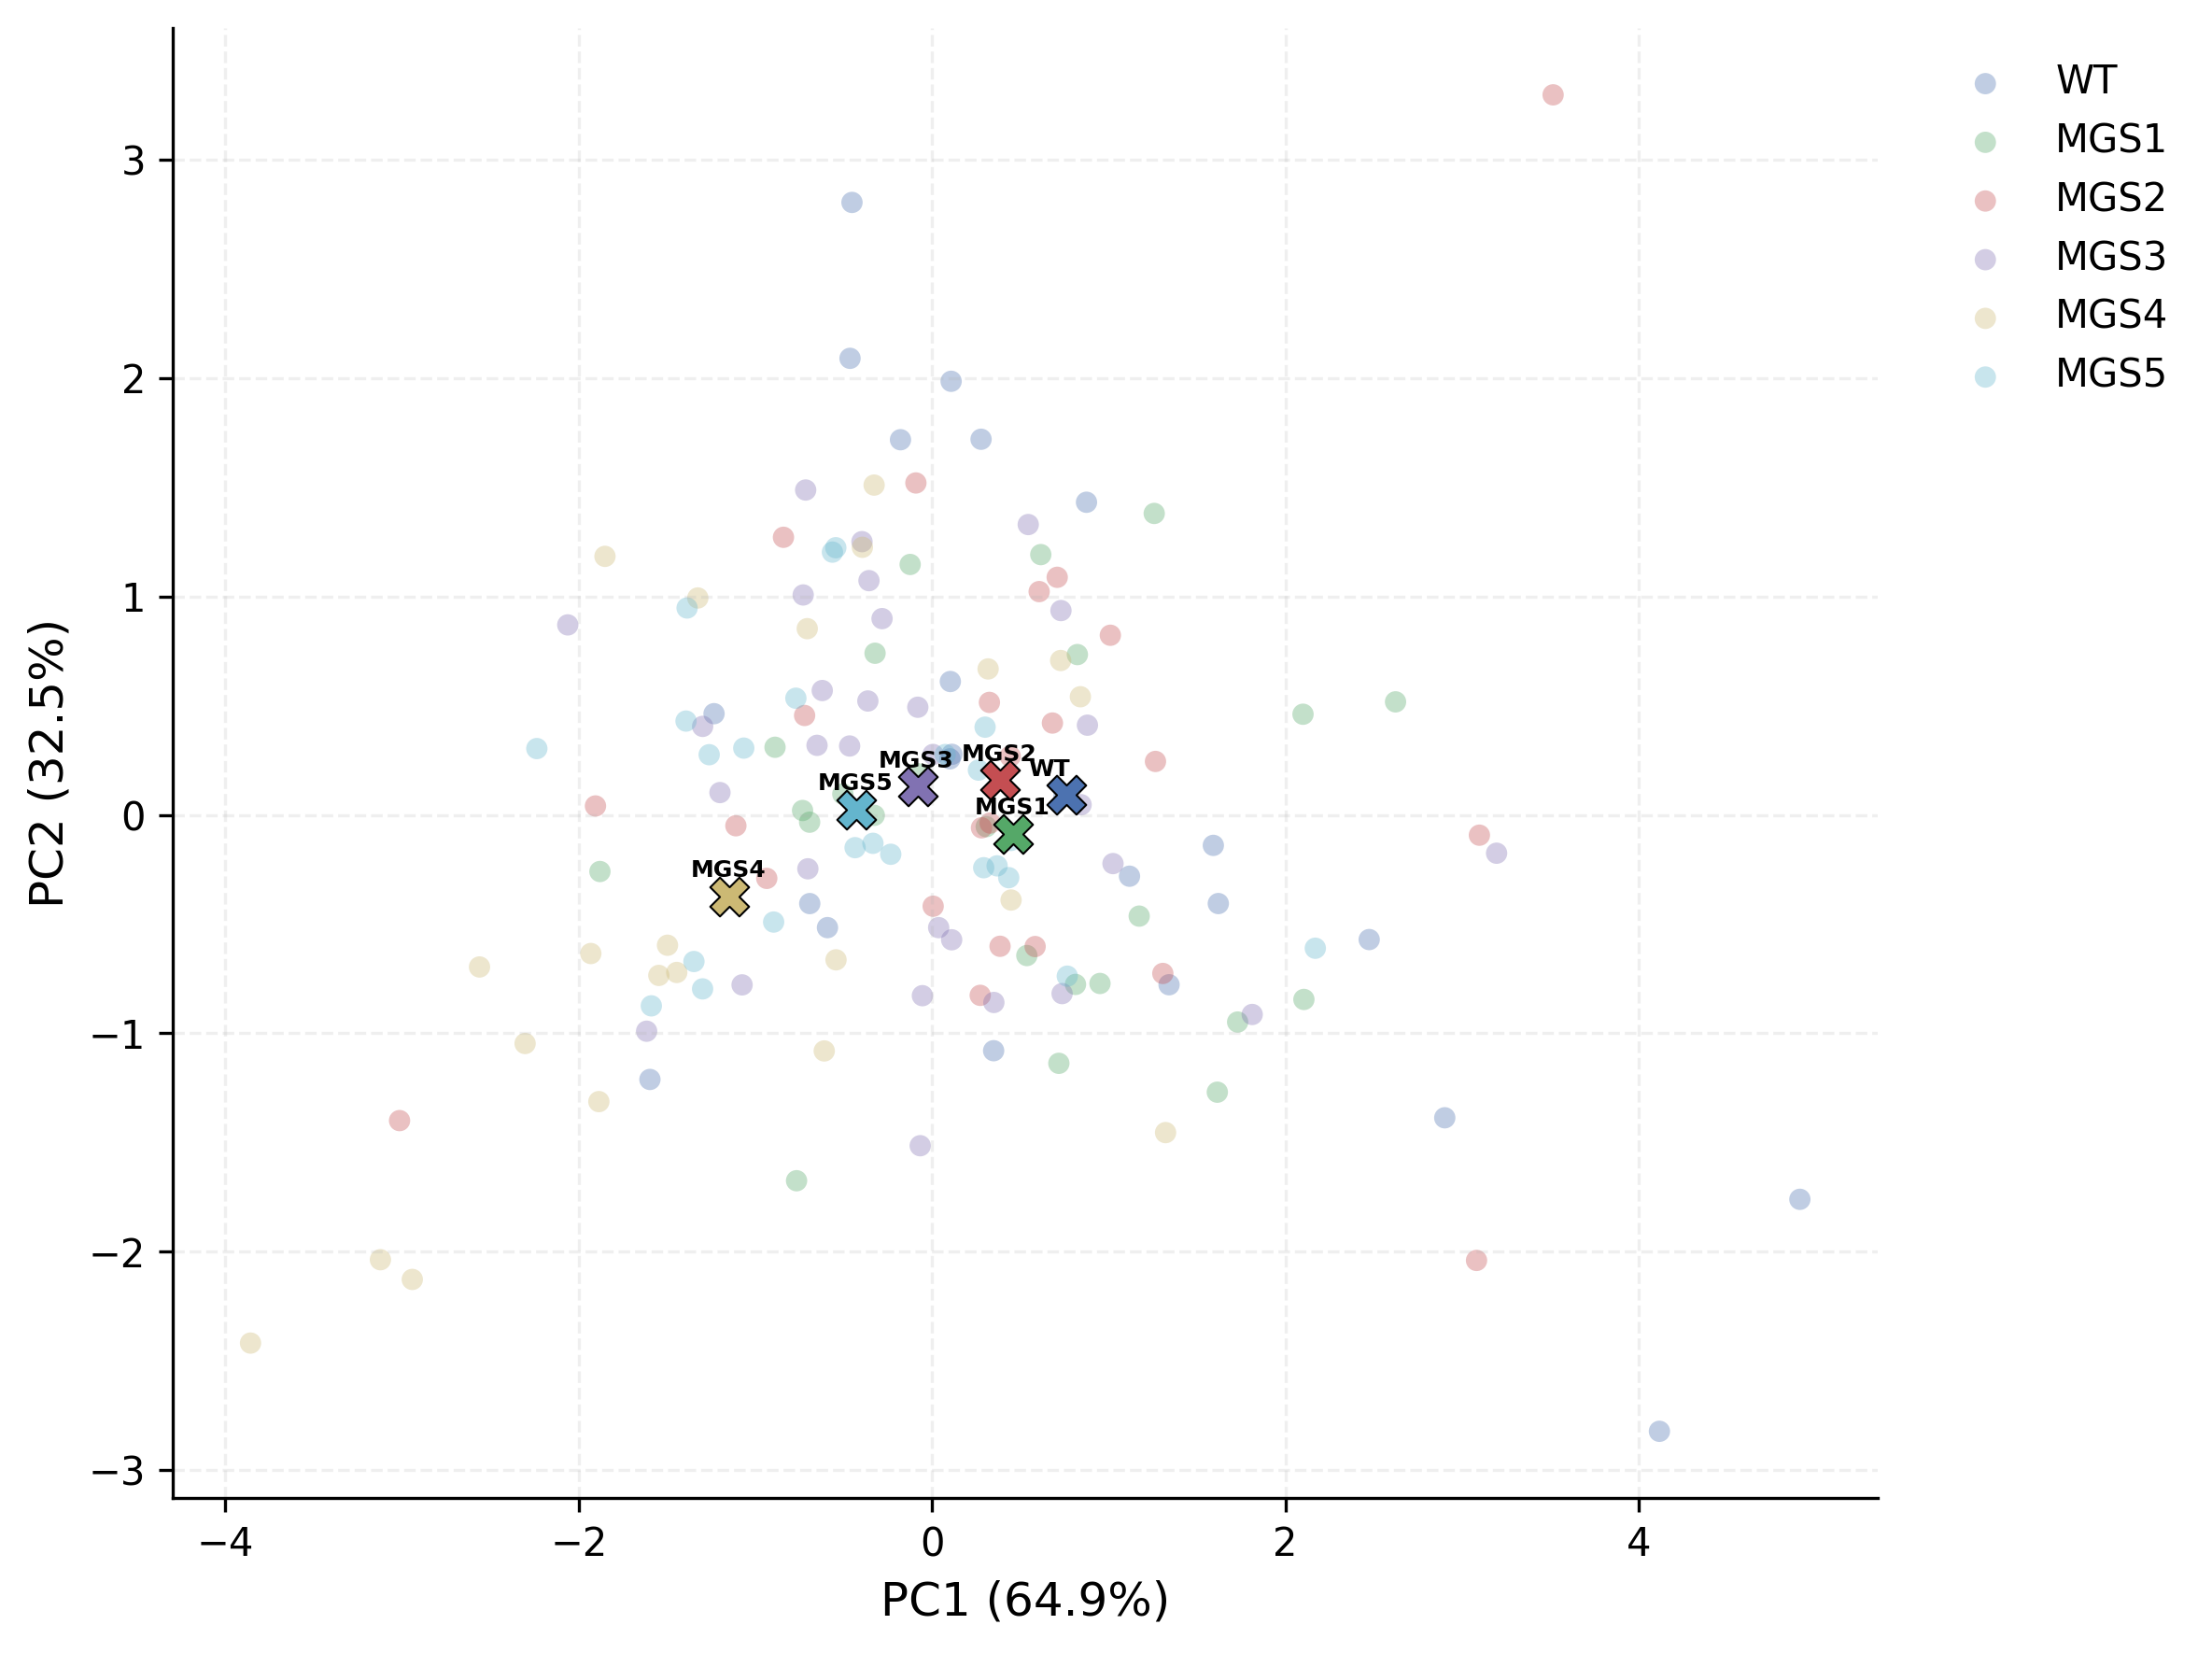

In [77]:
fig, ax = beautiful_pca_plot(
    pca_df,
    centroids,
    explained_variance=pca.explained_variance_ratio_
)

plt.show()

## Statistics

In [74]:
results = compare_pca_to_wt(pca_df)
results

,sample,PC1_p,PC2_p
0,MGS1,0.725481,0.757641
1,MGS2,0.693798,0.839781
2,MGS3,0.033453,0.767146
3,MGS4,0.000293,0.224458
4,MGS5,0.008582,0.906822
